---

### <center> 기본 설정 

---

In [2]:
import os 
import sys
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns   
import math
import scipy.stats as stats
from io import StringIO
from datetime import datetime, timedelta

import warnings 
warnings.filterwarnings("ignore")

In [8]:
# 폰트 깨짐 방지
import platform
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic') 
else:
    
    plt.rc('font', family='NanumGothic')

# 마이너스 기호방지
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
df = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\V2_merge.parquet')

In [ ]:
df.head()

,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,fashion_news_frequency,age,...,product_group_name,graphical_appearance_name,colour_group_name,perceived_colour_value_name,perceived_colour_master_name,department_name,index_name,index_group_name,section_name,garment_group_name
0,2018-09-20,2,663713001,29.99,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Black,Dark,Black,Expressive Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
1,2018-09-20,2,541518023,17.99,2,0,0,ACTIVE,NONE,24,...,Underwear,Solid,Light Pink,Dusty Light,Pink,Casual Lingerie,Lingeries/Tights,Ladieswear,Womens Lingerie,"Under-, Nightwear"
2,2018-09-20,7,505221004,8.99,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium Dusty,Pink,Tops Knitwear DS,Divided,Divided,Divided Selected,Knitwear
3,2018-09-20,7,685687003,9.99,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Pink,Medium,Pink,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers
4,2018-09-20,7,685687004,9.99,2,1,1,ACTIVE,Regularly,32,...,Garment Upper body,Melange,Dark Green,Dark,Green,Campaigns,Ladieswear,Ladieswear,Womens Everyday Collection,Special Offers


In [14]:
# RFM 지표 계산
df['t_dat'] = pd.to_datetime(df['t_dat'])
snapshot_date = df['t_dat'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (snapshot_date - x.max()).days), # 최근성
    Frequency=('t_dat', 'nunique'),                              # 방문 빈도
    Monetary=('price', 'sum')                                    # 총 구매 금액
).reset_index()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 분석에 사용할 컬럼 추출 (RFM)
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 데이터 스케일링 (단위를 일정하게 맞춤)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

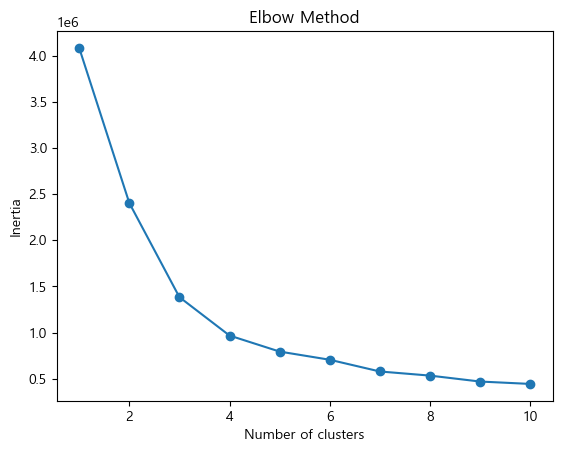

In [16]:
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [17]:
# 통계적 신뢰도 (중심극한정리)
## 확인 Silhouette Score(실루엣 계수)
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# 1. 무작위로 10,000개의 인덱스 추출 (130만 건 중 10만 건)
sample_size = 100000
np.random.seed(42) # 결과 재현을 위해 랜덤 시드 고정
indices = np.random.choice(len(rfm_scaled), sample_size, replace=False)

# 2. 추출된 인덱스에 해당하는 데이터만 따로 저장
rfm_scaled_sample = rfm_scaled[indices]

# 3. K=3일 때의 점수 계산
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
labels3 = kmeans3.fit_predict(rfm_scaled) # 전체 데이터 학습
labels3_sample = labels3[indices] # 샘플에 해당하는 라벨만 추출
score3 = silhouette_score(rfm_scaled_sample, labels3_sample)

# 4. K=4일 때의 점수 계산
kmeans4 = KMeans(n_clusters=4, init='k-means++', random_state=42)
labels4 = kmeans4.fit_predict(rfm_scaled) # 전체 데이터 학습
labels4_sample = labels4[indices] # 샘플에 해당하는 라벨만 추출
score4 = silhouette_score(rfm_scaled_sample, labels4_sample)

print(f"표본(10만건) 기준 K=3 실루엣 점수: {score3:.4f}")
print(f"표본(10만건) 기준 K=4 실루엣 점수: {score4:.4f}")

표본(10만건) 기준 K=3 실루엣 점수: 0.5022
표본(10만건) 기준 K=4 실루엣 점수: 0.5043


In [19]:
# 최적의 k=4로 모델 확정
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 각 클러스터별 평균값 계산 (원본 데이터 기준)
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).rename(columns={'Recency': '최근성(일)', 'Frequency': '방문횟수(번)', 'Monetary': '총구매금액($)'})

# 클러스터별 고객 수 확인
cluster_profile['고객수'] = rfm['Cluster'].value_counts()

print(cluster_profile.sort_values('총구매금액($)', ascending=False))

             최근성(일)    방문횟수(번)     총구매금액($)     고객수
Cluster                                            
3         29.652834  42.032065  3189.160889   35303
1         56.792164  18.131518  1019.053345  210709
0        127.564804   4.141481   200.952103  708223
2        536.825626   1.791610    97.952927  406684


1. **클러스터 3번** - VIP 고객 (최상위 핵심 고객) (최근성, 방문횟수, 총구매금액 모두 최상위권)

2. **클러스터 1번** - 충성 고객 (성장 잠재력이 높은 우수고객) (최근성 2위, 방문횟수 2위, 총 구매금액 2위) 

3. **클러스터 0번** - [타겟] 일반/관심 고객 (가장 큰 비중의 대중 고객) (앞선 군집보단 전체적으로 낮으나 고객수가 가장 많음)

4. **클러스터 2번** - 이탈 위험/휴면 고객 (관리가 필요한 고객) (마지막 방문이 약 2년 전, 사실상 서비스 이용을 멈춘 이탈층)

#### <center> Anova 분석, 사후 검정(Tukey HSD)

In [20]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. ANOVA 분석 (Monetary: 총 구매금액 기준)군집간에 평균차이가 있는가
f_val, p_val = stats.f_oneway(rfm[rfm['Cluster']==0]['Monetary'],
                              rfm[rfm['Cluster']==1]['Monetary'],
                              rfm[rfm['Cluster']==2]['Monetary'],
                              rfm[rfm['Cluster']==3]['Monetary'])

print(f"ANOVA 결과: F={f_val:.2f}, p-value={p_val:.4f}")

# 2. 사후 검정 (Tukey HSD)
# 어떤 군집끼리 구체적으로 차이가 나는지 확인
tukey = pairwise_tukeyhsd(endog=rfm['Monetary'],     # 데이터
                          groups=rfm['Cluster'],      # 그룹
                          alpha=0.05)                # 유의수준
print(tukey)

ANOVA 결과: F=1367160.88, p-value=0.0000
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     0      1  818.1013   0.0  816.0621  820.1405   True
     0      2 -102.9992   0.0  -104.616 -101.3824   True
     0      3 2988.2088   0.0 2983.7274 2992.6901   True
     1      2 -921.1004   0.0 -923.3062 -918.8947   True
     1      3 2170.1075   0.0 2165.3816 2174.8334   True
     2      3  3091.208   0.0 3086.6484 3095.7675   True
--------------------------------------------------------


#### <center> 군집별 총 매출 비중 계산

In [21]:
# 군집별 매출 비중 계산 
# 소수의 핵심 고객이 전체 매출을 견인하고 있는가?
# (해당 군집 고객수 ÷ 전체 고객수 합계) × 100
# (해당 군집 매출액 ÷ 전체 매출액 합계) × 100
impact = rfm.groupby('Cluster').agg({
    'customer_id': 'count',
    'Monetary': 'sum'
}).rename(columns={'customer_id': '고객수', 'Monetary': '총매출'})

impact['고객비중(%)'] = (impact['고객수'] / impact['고객수'].sum()) * 100
impact['매출비중(%)'] = (impact['총매출'] / impact['총매출'].sum()) * 100

print(impact.sort_values('매출비중(%)', ascending=False))

            고객수          총매출    고객비중(%)    매출비중(%)
Cluster                                           
1        210709  214723712.0  15.482847  42.146862
0        708223  142318896.0  52.040055  27.934944
3         35303  112586944.0   2.594056  22.099033
2        406684   39835888.0  29.883042   7.819153


####  <center> Life Time (LTV)

In [ ]:
# 구분,일반 RFM (K-means용),Lifetimes 모델 (LTV용)
# 정의,현재(기준일)로부터 마지막 구매가 얼마나 최근인가?,첫 구매일로부터 마지막 구매가 얼마나 나중에 일어났는가?
# 수치 의미,작을수록 최근 고객 (좋음),클수록 오랫동안 우리 서비스를 이용 중 (좋음)
# 계산식,기준일 - 마지막 구매일,   마지막 구매일 - 첫 구매일

ltv_df = rfm.copy()

# 값 가공 (이미 Frequency가 구매 일수/횟수라면 1을 빼서 '재구매' 횟수로 만듭니다) 
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']

# 원본 데이터 df를 활용해 고객별 첫 구매일 계산
customer_first_purchase = df.groupby('customer_id')['t_dat'].min().reset_index()
customer_first_purchase.columns = ['customer_id', 'first_purchase']

# 기존 rfm 데이터프레임과 병합
ltv_df = pd.merge(rfm, customer_first_purchase, on='customer_id')

# T (Age): 첫 구매일부터 snapshot_date까지의 총 기간(일 단위)
ltv_df['T'] = (snapshot_date - ltv_df['first_purchase']).dt.days

# LTV 모델용 Recency: 첫 구매일부터 마지막 구매일까지의 기간 (lifetimes 모델 기준)
# 주의: 기존 Recency(기준일 - 마지막 구매일)와는 다른 개념입니다.
ltv_df['recency_ltv'] = ltv_df['T'] - ltv_df['Recency']

# Frequency: 재구매 횟수 (전체 방문횟수 - 1)
ltv_df['frequency_ltv'] = ltv_df['Frequency'] - 1

# Monetary: 1회 방문당 평균 구매 금액
ltv_df['monetary_avg'] = ltv_df['Monetary'] / ltv_df['Frequency']

In [ ]:
from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 (전체 고객 대상)고객이 앞으로 몇번 더 올까를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 더 왔을 때 얼마를 쓸까?"를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 365일간의 예상 LTV(CLV) 계산
ltv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=365, discount_rate=0
)

# [단계 4] Cluster 0의 잠재력 입증
cluster_0 = ltv_df[ltv_df['Cluster'] == 0]
print("--- Cluster 0 예상 가치 요약 ---")
print(cluster_0['predicted_clv'].describe())

KeyboardInterrupt: 

#### <center> BG/NBD , GAMMA-GAMMA 모델

In [ ]:
# BG/NBD & Gamma-Gamma 모델: 고객의 구매 빈도와 평균 결제 금액을 결합하여 
# 향후 일정 기간 내 발생할 예상 매출을 계산합니다.
# Cluster 0 중에서도 LTV가 높게 예측되는 집단이 있다면 타겟팅의 강력한 근거가 됩니다.
#독립성 확인: Gamma-Gamma 모델은 "구매 빈도와 평균 금액 사이에 상관관계가 낮다"는 전제가 필요합니다.
# lifetimes 패키지의 Gamma-Gamma 모델은 "첫 번째 구매를 
# 제외한 재구매 시의 평균 금액"을 넣는 것을 권장하거나, 
# 혹은 전체 평균을 넣더라도 frequency가 0인 고객(단발성 고객)은 제외하고 학습시켜야 합니다.

from lifetimes import BetaGeoFitter, GammaGammaFitter

# [단계 1] BG/NBD 모델 학습 (전체 고객 대상)고객이 앞으로 몇번 더 올까를 예측
bgf = BetaGeoFitter(penalizer_coef=0.01)
# lifetimes 모델 공식 기준: frequency_ltv, recency_ltv, T 사용
bgf.fit(ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'])

# [단계 2] Gamma-Gamma 모델 학습 (수익성 예측)한 번 더 왔을 때 얼마를 쓸까?"를 예측
returning_customers = ltv_df[ltv_df['frequency_ltv'] > 0]
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(returning_customers['frequency_ltv'], returning_customers['monetary_avg'])

# [단계 3] 향후 12개월간의 예상 LTV(CLV) 계산
ltv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    ltv_df['frequency_ltv'], ltv_df['recency_ltv'], ltv_df['T'], ltv_df['monetary_avg'],
    time=12, discount_rate=0.01
)

# [단계 4] Cluster 0의 잠재력 입증
cluster_3 = ltv_df[ltv_df['Cluster'] == 3]
print("--- Cluster 0 예상 가치 요약 ---")
print(cluster_3['predicted_clv'].describe())

--- Cluster 3 예상 가치 요약 ---
count    3.530100e+04
mean     1.343029e+03
std      6.100959e+02
min      1.511183e-25
25%      9.545231e+02
50%      1.231801e+03
75%      1.618646e+03
max      8.238447e+03
Name: predicted_clv, dtype: float64


In [ ]:
# Gamma-Gamma 모델의 수학적 가정(Assumption)을 데이터가 실제로 충족하는지 검증하기 위해서입니다.
# Cluster 0이면서 재구매 경험이 있는 고객들만 필터링
cluster_0_returning = ltv_df[(ltv_df['Cluster'] == 0) & (ltv_df['frequency_ltv'] > 0)]

# 해당 집단 내부에서의 상관관계 확인
correlation = cluster_0_returning[['frequency_ltv', 'monetary_avg']].corr()
print(correlation)

               frequency_ltv  monetary_avg
frequency_ltv       1.000000     -0.187929
monetary_avg       -0.187929      1.000000


#### <center> 군집 0번 고객 분석

In [27]:
# Cluster 0에 해당하는 고객들만 필터링
target_cluster_df = ltv_df[ltv_df['Cluster'] == 0]

# 해당 고객들의 ID만 리스트(배열)로 추출
cluster_0_customers = target_cluster_df['customer_id'].unique()

print(f"타겟 고객수확인: {len(cluster_0_customers):,}명")

# 머신러닝 용 저장
target_cluster_df[['customer_id']].to_csv('target_cluster_0_ids.csv', index=False)

타겟 고객수확인: 708,223명


---

### <Center> 1. 머신러닝 (Random Forest)

---

In [ ]:
import pandas as pd
target_ids = pd.read_csv('target_cluster_0_ids.csv')

#  테이블 churn_predictions_df과 결합 (Inner Join)
# churn_predictions_df 에는 'customer_id'와 'churn_probability' 컬럼이 있다고 가정
final_target_pool = pd.merge(target_ids, churn_predictions_df, on='customer_id', how='inner')

# 3. 그 중에서 이탈 확률이 50% ~ 60% 인 황금 타겟만 최종 추출!
golden_target = final_target_pool[
    (final_target_pool['churn_probability'] >= 0.50) & 
    (final_target_pool['churn_probability'] <= 0.60)
]

print(f"최종 고객 수: {len(golden_target):,}")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import gc

# V2_merge_parquet 로딩
df = pd.read_parquet(r'../Data Folder\H&M dataset\H&m parquet dataset\V2_merge.parquet')

# 모델링을 위한 고객 단위 데이터로 집계
# 기준일: 데이터의 마지막 날짜 (2020-09-22)
max_date = df['t_dat'].max()
cutoff_date = pd.to_datetime('2020-07-22') # 마지막 2개월을 이탈 여부 판단 타겟으로 사용

# 관찰 기간 데이터만 필터링 =  최근 6개월 이내 활동한 고객 대상
start_date = pd.to_datetime('2020-01-01')
df_obs = df[(df['t_dat'] >= start_date) & (df['t_dat'] <= cutoff_date)]
df_pred = df[df['t_dat'] > cutoff_date]

# RFM 계산
customer_features = df_obs.groupby('customer_id').agg(
    Recency=('t_dat', lambda x: (cutoff_date - x.max()).days),
    Frequency=('article_id', 'count'),
    Monetary=('price', 'sum'),
    Age=('age', 'max'),
    Active=('Active', 'max'),
    FN=('FN', 'max')
).reset_index()

# 카테고리 피처 변환 --> club_member_status
# 범주형 데이터는 모델이 이해할 수 있게 ''One-Hot Encoding'' 처리
status_mode = df_obs.groupby('customer_id')['club_member_status'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'UNKNOWN')
customer_features = customer_features.merge(status_mode, on='customer_id', how='left')
customer_features = pd.get_dummies(customer_features, columns=['club_member_status'], drop_first=True)

# (Target Label) 생성
# 예측 기간(7/23 ~ 9/22)에 구매 이력이 없으면 이탈(1), 있으면 잔존(0)
purchased_later = df_pred['customer_id'].unique()
customer_features['Churn'] = (~customer_features['customer_id'].isin(purchased_later)).astype(int)

print(f"총: {len(customer_features):,}명 (이탈률: {customer_features['Churn'].mean()*100:.1f}%)")

# 머신러닝 데이터 분할 (Train / Test)
X = customer_features.drop(columns=['customer_id', 'Churn']) 
y = customer_features['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 학습 ''Random Forest'' 모델로
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 모델 평가
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

#  ZEP 초대 타겟 리스트 추출 --> (이탈 확률 75% 이상 & 상위 구매자 군집) 
customer_features['Churn_Probability'] = rf_model.predict_proba(X)[:, 1]

# VIP 조건은 --> 구매 금액(Monetary) 상위 20% 이면서 이탈 확률 75% 이상
monetary_threshold = customer_features['Monetary'].quantile(0.80)
target_vips = customer_features[
    (customer_features['Monetary'] >= monetary_threshold) & 
    (customer_features['Churn_Probability'] >= 0.50)
]

print(f"초대 예상 총 인원은 {len(target_vips):,}명")
# target_vips.to_csv('zep_target_vips.csv', index=False)

# 메모리 정리
del df, df_obs, df_pred
gc.collect()

총: 768,804명 (이탈률: 59.5%)
              precision    recall  f1-score   support

           0       0.60      0.64      0.62     62242
           1       0.74      0.71      0.73     91519

    accuracy                           0.68    153761
   macro avg       0.67      0.68      0.67    153761
weighted avg       0.69      0.68      0.68    153761

ROC-AUC Score: 0.7351
초대 예상 총 인원은 43명 확정!


1299

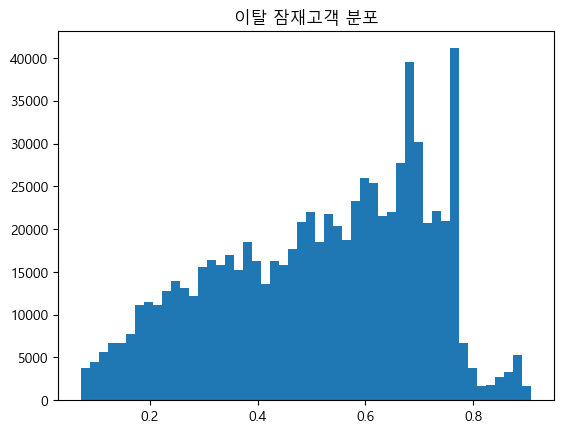

재수정 타겟 인원수: 8,913


In [9]:
# 이탈 고객 분포
import matplotlib.pyplot as plt
plt.hist(customer_features['Churn_Probability'], bins=50)
plt.title("이탈 잠재고객 분포")
plt.show()

# 타겟 인원수 시뮬레이션
# 0.75 대신 0.5나 0.6으로 낮췄을 때 인원수가 몇 명인지 체크
target_v2 = customer_features[
    (customer_features['Monetary'] >= monetary_threshold) & 
    (customer_features['Churn_Probability'] >= 0.50) ## 일단 0.5로 재확인.
]
print(f"재수정 타겟 인원수: {len(target_v2):,}")

---

### <center> 2. XGBoost 성능 실험

---

In [10]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# 불균형 데이터 가중치 계산 (잔존자 수 / 이탈자 수)
# y_train = 0(잔존), 1(이탈)
ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)

# 모델 선언 및 하이퍼파라미터 세팅
xgb_model = xgb.XGBClassifier(
    n_estimators=200,          # 나무의 개수
    max_depth=5,               # 트리의 깊이는 RF보다 낮게 설정해 과적합 방지함.
    learning_rate=0.05,        # 학습률
    scale_pos_weight=ratio,    # 불균형 클래스 가중치
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# 모델 학습
xgb_model.fit(X_train, y_train)

# 성능 평가
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

              precision    recall  f1-score   support

           0       0.60      0.65      0.62     62242
           1       0.75      0.70      0.72     91519

    accuracy                           0.68    153761
   macro avg       0.67      0.68      0.67    153761
weighted avg       0.69      0.68      0.68    153761

ROC-AUC Score: 0.7376


---

### <center> 3. Lgbm 모델 실험 

---

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# 학습 시작
# 모델 선언 (class_weight='balanced' 로 불균형 자동 조정 옵션)
lgbm_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # CPU 병렬 처리로 속도 향상
)

# 2. 모델 학습
# (X_train, y_train은 기존 거 사용)
lgbm_model.fit(X_train, y_train)

# 성능 평가 
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# 결과
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lgbm):.4f}")


# Cluster 0번과 결합하여 '확실한 타겟' 추출
# 1. ltv_df : 클러스터링을 완료한 데이터프레임 (Cluster 컬럼 존재)
# 2. customer_features : 전처리해둔 '전체 고객 피처' 원본 데이터 (train_test_split 하기 전 데이터임)
# ------------------------------------------------------------------------- # 

# 결과에서 'Cluster 0'인 고객 ID만 리스트로 뽑기
# 분석팀 데이터프레임 이름이 ltv_df 라고 가정
cluster_0_ids = ltv_df[ltv_df['Cluster'] == 0]['customer_id'].unique()
print(f"클러스터 0번 총 인원 {len(cluster_0_ids):,}명")

# 전체 피처 데이터에서 Cluster 0번 고객들의 데이터만 가져오기
# (customer_features는머신러닝용으로 만든 전체 데이터프레임 이름)
target_pool = customer_features[customer_features['customer_id'].isin(cluster_0_ids)].copy()

# 모델에 넣기 위해 불필요한 컬럼 제거 (학습할 때 썼던 X_train과 컬럼 똑같이 맞춰야 함!!!!)
# 보통 customer_id나 정답지(Target) 컬럼은 빼야 함
feature_cols = X_train.columns.tolist() # 학습때 쓴 컬럼 명단 그대로 가져오기
X_target = target_pool[feature_cols]

# Cluster 0번 고객들의 이탈 확률 예측 
target_probs = lgbm_model.predict_proba(X_target)[:, 1]

# 예측 결과를 데이터프레임에 붙이기
target_pool['churn_prob'] = target_probs

# 최종필터링: 이탈 확률 50% ~ 60% 사이인 '이탈 잠재 고객'만 추출
golden_target = target_pool[
    (target_pool['churn_prob'] >= 0.50) & 
    (target_pool['churn_prob'] <= 0.60)
]

### 최종 결과 확인
print(f"최종 인원: {len(golden_target):,}명")

# 파일로 저장 (팀 배포)
golden_target[['customer_id', 'churn_prob']].to_csv('Final_ZEP_Target_List.csv', index=False)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 366074, number of negative: 248969
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 703
[LightGBM] [Info] Number of data points in the train set: 615043, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

- 모델 성능 (ROC-AUC): 0.7377 --> 0.75까지 올리는걸 목표로

- 클러스터_0의 총 인원은 708,223명

- 그중 이탈 잠재 고객 예츨모델 --> 95,968명 [최종 타겟 고객]

--> 전원에게 초대장을 발송한다면 ZEP에 실제로 접속할 인원은?
(가설 5~10%): 약 4500명 ~ 9500명

이탈 방어 성공률을 30%로 잡으면 3000명 정도 방어
-> 클러스터_0의 인당 평균 구매액은 약 201 크로나
-> 예상 매출 방어 효과는 3000 X 201크로나 = 

---

### <center> LIFT 변환 -->  물리적 거리

---

In [ ]:
# 1. Cluster_0 고객 아이디만 추출
c0_users = rfm[rfm['Cluster'] == 0]['customer_id']

# 2. 이들이 구매한 상품 정보 결합 (df는 원본 거래 데이터)
c0_data = df[df['customer_id'].isin(c0_users)]

# 3. 이들이 가장 많이 산 '카테고리'와 '상품명' Top 10
print("Cluster 0가 가장 선호하는 카테고리 Top 10")
print(c0_data['product_type_name'].value_counts().head(10))

print("Cluster 0가 가장 많이 산 구체적 상품명 Top 10")
print(c0_data['product_group_name'].value_counts().head(10))

# 4. 이들의 평균 연령대 확인
avg_age = c0_data['age'].mean()
print(f"Cluster 0의 평균 나이: {avg_age:.1f}세")

Cluster 3가 가장 선호하는 카테고리 Top 10
product_type_name
Trousers           1156634
Dress               822469
Sweater             742871
T-shirt             691598
Top                 451578
Bra                 439403
Vest top            437242
Bikini top          392057
Blouse              382220
Swimwear bottom     372018
Name: count, dtype: int64
Cluster 3가 가장 많이 산 구체적 상품명 Top 10
product_group_name
Garment Upper body    3539496
Garment Lower body    1978506
Garment Full body      911250
Swimwear               861531
Underwear              847299
Accessories            466060
Socks & Tights         234506
Shoes                  178211
Nightwear               99167
Unknown                 34994
Name: count, dtype: int64
Cluster 3의 평균 나이: 35.1세


1. Trousers (영국식 팬츠) --> 슬랙스같은 종류

2. dress (원피스) 

3. sweater (니트 종류)

4. T-shirt (티셔츠)

5. Top (여성 상의)

6. Bra (브래지어)

7. Top (상의) 

8. bikini top (비키니 상의)

9. blouse (블라우스)

10. Swimwear bottom (수영복 바지) 
